INSTALASI DAN IMPORT

In [ ]:
!pip install PySastrawi emoji wordcloud tqdm requests

In [ ]:
import re
import json
import requests

import emoji
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter
from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

tqdm.pandas()

UPLOAD DATA

In [ ]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/cafauzi13/ESG_SentimentAnalysis/main/data/raw_data.csv"
url2 = "https://raw.githubusercontent.com/cafauzi13/ESG_SentimentAnalysis/main/data/raw_multatuli.csv"

dfs = []
for url in [url1, url2]:
    temp = pd.read_csv(url)
    print(f"Loaded: {url.split('/')[-1]} -> {len(temp)} baris")
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal setelah digabung: {len(df)} baris")
print(f"Kolom: {df.columns.tolist()}")
df.head()
tag_summary = df['Tag'].value_counts().reset_index()
tag_summary.columns = ['Tag', 'Jumlah']
print(tag_summary)
df.head()

Loaded: raw_data.csv -> 449 baris
Loaded: raw_multatuli.csv -> 39 baris

Total setelah digabung: 488 baris
Kolom: ['Link', 'Sentiment', 'Penerbit', 'Tag', 'Perusahaan', 'Tahun', 'Isi Berita Clean']
             Tag  Jumlah
0         Social     128
1  Investigation     105
2    Environment      89
3        Finance      88
4     Governance      78


,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean
0,https://finansial.bisnis.com/read/20230908/90/...,Positif,Bisnis.com,Finance,Bank BRI,2023,"Bisnis.com, JAKARTA - Sukses dalam transisi en..."
1,https://finansial.bisnis.com/read/20230315/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,Nyaman tanpa iklan. Langganan BisnisPro Nyaman...
2,https://finansial.bisnis.com/read/20231108/90/...,Positif,Bisnis.com,Governance,Bank Mandiri,2023,"Bisnis.com, JAKARTA - Bank Mandiri berhasil me..."
3,https://finansial.bisnis.com/read/20250206/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,"Bisnis.com, JAKARTA - Bank Mandiri terus mempe..."
4,https://finansial.bisnis.com/read/20250209/90/...,Positif,Bisnis.com,Environment,Bank Mandiri,2025,"Bisnis.com, JAKARTA - Bank Mandiri kembali men..."


SETUP STOPWORDS

In [ ]:
# Stopwords dari Sastrawi
sastrawi_stopwords = set(StopWordRemoverFactory().get_stop_words())

# Combined stopwords dari GitHub louisowen6
url_stopwords = "https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_stop_words.txt"
try:
    response = requests.get(url_stopwords, timeout=10)
    response.raise_for_status()
    combined_stopwords = set(response.text.splitlines())
    print(f"Combined stopwords berhasil dimuat: {len(combined_stopwords)} kata")
except Exception as e:
    print(f"Gagal memuat combined stopwords: {e}")
    print("Fallback ke Sastrawi saja.")
    combined_stopwords = set()

# Menggabungkan keduanya
all_stopwords = sastrawi_stopwords | combined_stopwords

# Kata-kata ESG penting yang TIDAK boleh dihapus meskipun ada di stopwords
# (beberapa stopwords list memasukkan kata umum yang justru bermakna di konteks ESG)
esg_whitelist = {
    "lingkungan", "sosial", "tata", "kelola", "emisi", "karbon",
    "hijau", "berkelanjutan", "keberlanjutan", "iklim", "energi",
    "investasi", "transparansi", "akuntabilitas", "komunitas",
    "karyawan", "supplier", "stakeholder", "direksi", "komisaris",
    # Negasi langsung
    "tidak", "bukan", "belum", "tanpa", "non", "kurang", "minim", "nihil", "absen", "ketiadaan", "ketidakhadiran",
}
all_stopwords -= esg_whitelist

print(f"Total stopwords efektif: {len(all_stopwords)} kata")
print(f"Whitelist ESG dilindungi: {len(esg_whitelist)} kata")

Combined stopwords berhasil dimuat: 675 kata
Total stopwords efektif: 882 kata
Whitelist ESG dilindungi: 31 kata


STEMMER

In [ ]:
stemmer = StemmerFactory().create_stemmer()

In [ ]:
stem_whitelist = {
    # Konsep keberlanjutan
    "berkelanjutan", "keberlanjutan", "ketidakberlanjutan",
    # Konsep tata kelola
    "ketidakpatuhan", "ketidaktransparanan", "ketidakakuntabilitasan",
    "akuntabilitas", "transparansi",
    # Istilah ESG teknis
    "esg", "greenwashing", "greenwash",
    "emisi", "karbon", "dekarbonisasi",
    "biodiversitas", "ekosistem",
    "stakeholder", "shareholder",
    # Kata negasi majemuk — jangan dipecah
    "ketidaksesuaian", "ketidakpedulian",
}

SINGKATAN FORMAL

In [ ]:
abbrev_dict = {
    # Singkatan kata umum
    "yg"  : "yang",
    "tdk" : "tidak",
    "dg"  : "dengan",
    "dgn" : "dengan",
    "krn" : "karena",
    "dr"  : "dari",
    "utk" : "untuk",
    "dlm" : "dalam",
    "thd" : "terhadap",
    "ttg" : "tentang",
    "tsb" : "tersebut",
    "spt" : "seperti",
    "kpd" : "kepada",
    "sdh" : "sudah",
    "blm" : "belum",
    "msh" : "masih",
    "dpt" : "dapat",
    "hrs" : "harus",
    "mjd" : "menjadi",
    "tmsk": "termasuk",
    # Singkatan institusi (sering muncul di berita ESG)
    "pemda" : "pemerintah daerah",
    "pemkot": "pemerintah kota",
    "pemkab": "pemerintah kabupaten",
}

POLA IKLAN & NOISE

In [ ]:
checks = [
    ('Reporter di awal',       r'^\s*(?:reporter|penulis)\s*[:\-]?\s*\w+'),
    ('Editor di awal',         r'^\s*editor\s*[:\-]?\s*\w+'),
    ('KONTAN.CO.ID',           r'KONTAN\.CO\.ID'),
    ('Copyright',              r'copyright'),
    ('All Rights Reserved',    r'all rights? reserved'),
    ('Pewarta',                r'\bpewarta\b'),
    ('Iklan WIB Tempo',        r'iklan\s+\d{1,2}\s+\d{2}\s+wib'),
    ('logo Selamat',           r'logo\s+selamat'),
    ('Republikasi',            r'\brepublikasi\b'),
    ('Esai bagian serial',     r'esai ini merupakan bagian'),
    ('Laporan ditulis sumber', r'laporan ini ditulis dengan sumber'),
]


# ==================================================
# NOISE PATTERNS
# ==================================================
noise_patterns = [
    # Iklan & subscription
    r'nyaman tanpa iklan[^\n]*',
    r'langganan[^\n]*premium[^\n]*',
    r'subscribe[^\n]*',
    r'daftar sekarang[^\n]*',
    r'berlangganan[^\n]*',
    r'akses premium[^\n]*',
    r'dapatkan akses[^\n]*',
    r'baca juga[^\n]*',
    r'baca juga:[^\n]*',
    r'artikel terkait[^\n]*',
    r'klik di sini[^\n]*',
    r'download aplikasi[^\n]*',
    r'Jika Anda menyukai cerita ini, bagikan dengan orang lain[^\n]*',
    r'Iran Janjikan Hadiah bagi Warga yang Bisa Tangkap Pilot Jet Tempur AS',

    # Tempo header: "Iklan 09 05 WIB Dengarkan artikel Bagikan Gabung [Circle/nama artikel]"
    r'iklan\s+\d{1,2}\s+\d{2}\s+wib\s+dengarkan artikel\s+bagikan\s+gabung(?:\s+(?:tempo\s+)?circle)?',

    # Validnews header: "logo Selamat Logo twitter facebook instagram youtube Senin 17 13 WIB"
    r'logo\s+selamat\s+logo(?:\s+\w+){1,10}\s+\d{1,2}\s+\d{2}\s+wib',

    # Project Multatuli header
    r'^\s*republikasi\s*',

    # Antaranews footer
    r'pewarta\s+[A-Za-z\s]+editor\s+[A-Za-z\s]+copyright[^\n]*',
    r'dilarang keras mengambil konten[^\n]*',
    r'melakukan crawling atau pengindeksan[^\n]*',
    r'kirim komentar[^\n]*',

    # Jpnn.com footer
    r'redaktur\s+reporter\s+[A-Za-z\s]+silakan baca konten[^\n]*',
    r'silakan baca konten menarik lainnya[^\n]*',
    r'PT\. Jaringan Pemberitaan Nusantara[^\n]*',

    # Navigasi website
    r'please update your browser[^\n]*',
    r'enable javascript[^\n]*',
    r'halaman tidak ditemukan[^\n]*',
    r'page not found[^\n]*',
    r'Halo, Profile Kirim Images Logout Masuk ke akun Anda Belum punya akun\? Daftar Akun Pedoman Media Siber Hubungi Kami Privacy Policy Redaksi Download TribunX untuk Android iOS [^\n]*',
    r'Please select which cookies you are willing to store\. Cookie ini akan memberi Anda pengalaman yang lebih baik dari situs web kami\. Anda akan dapat menyembunyikan spanduk penerimaan cookie dan menggunakan fitur situs web dengan lebih baik\. Tidak menerima cookie ini akan memberi Anda pengalaman bebas cookie\. Cookies ini membantu meningkatkan kinerja Greenpeace\.org\. Mereka diatur untuk mengumpulkan data seperti berapa lama pengguna bertahan di suatu halaman atau tautan mana yang diklik\. Ini membantu kami membuat konten yang lebih baik berdasarkan pengalaman Anda menavigasi situs web\.',

    # Footer/header umum
    r'hak cipta[^\n]*',
    r'copyright[^\n]*',
    r'all rights reserved[^\n]*',
    r'all right reserved[^\n]*',
    r'redaksi[^\n]*hubungi[^\n]*',
    r'ikuti kami di[^\n]*',
    r'follow us[^\n]*',
    r'share artikel[^\n]*',
    r'bagikan artikel[^\n]*',
    r'Catatan Artikel ini merupakan opini pribadi penulis dan tidak mencerminkan pandangan Redaksi[^\n]',

    # Artefak HTML
    r'\xa0',
    r'\*\*\*',
    r'[\(\)]',

]


DEEP CLEAN HEADER AND FOOTER



In [ ]:
def deep_clean_header_footer(row):

    text      = str(row['Isi Berita Clean']).strip()
    publisher = str(row['Penerbit']).strip()

    # HEADER CLEANING (hanya area 250 karakter awal)
    header_area = text[:250]
    body_area   = text[250:]

    # Hapus domain website
    header_area = re.sub(
        r'(?:www\.)?[A-Za-z0-9\-\.]+\.(?:com|co\.id|id|co)',
        '',
        header_area,
        flags=re.IGNORECASE
    )

    # Hapus format domain penerbit uppercase di header
    # contoh: "KONTAN.CO.ID - JAKARTA."  "ANTARANEWS.COM -"
    header_area = re.sub(
        r'[A-Z0-9\-]+\.(?:CO\.ID|COM|ID|CO)\s*[-–]\s*',
        '',
        header_area
    )

    # Hapus lokasi umum
    header_area = re.sub(
        r'\b(?:jakarta|bandung|surabaya|medan|semarang|makassar|'
        r'denpasar|bogor|depok|bekasi|yogyakarta|antara)\b',
        '',
        header_area,
        flags=re.IGNORECASE
    )

    # Hapus media phrases
    header_area = re.sub(
        r'(?:media network|circle info bisnis|circle info nasional)',
        '',
        header_area,
        flags=re.IGNORECASE
    )

    # Hapus reporter/editor/penulis di area header
    header_area = re.sub(
        r'(?:reporter|editor|penulis|author|by)\s*[:\-]?\s*[A-Za-zÀ-ÿ\s\.]+',
        '',
        header_area,
        flags=re.IGNORECASE
    )

    # Hapus tanggal Indonesia + English
    header_area = re.sub(
        r'\b(?:'
        r'\d{1,2}\s+(?:januari|februari|maret|april|mei|juni|juli|agustus|'
        r'september|oktober|november|desember|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec|'
        r'january|february|march|april|may|june|july|august|september|october|november|december)'
        r'\s+\d{4}'
        r'|'
        r'(?:januari|februari|maret|april|mei|juni|juli|agustus|'
        r'september|oktober|november|desember|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec|'
        r'january|february|march|april|may|june|july|august|september|october|november|december)'
        r'\s+\d{1,2},?\s+\d{4}'
        r')\b',
        '',
        header_area,
        flags=re.IGNORECASE
    )

    # Hapus nama publisher jika ketemu di header
    if publisher.lower() != 'nan' and publisher != '':
        header_area = re.sub(
            re.escape(publisher),
            '',
            header_area,
            flags=re.IGNORECASE
        )

    # Hapus separator sisa di header
    header_area = re.sub(r'^[\s\-\|\.,:]+', '', header_area)
    header_area = re.sub(r'[\s\-\|\.,:]+', ' ', header_area).strip()

    # Menggabungkan kembali
    text = (header_area + ' ' + body_area).strip()

    # FOOTER CLEANING
    footer_triggers = [
        # Umum
        'Cek Berita dan Artikel yang lain di Google News',
        'Simak berita lainnya seputar',
        'Member of',
        'Baca Selengkapnya',
        'Lihat Juga',
        'Baca juga',

        # Kompas, Merdeka, Antara, dll
        'Copyright',
        'All Rights Reserved',
        'All Right Reserved',

        # Antaranews
        'Pewarta',

        # Jpnn.com
        'Redaktur Reporter',
        'Silakan baca konten menarik',

        # Kompas opinion
        'Penulis Editor',

        # Project Multatuli
        'Esai ini merupakan bagian dari serial opini',
        'Laporan ini ditulis dengan sumber',
        'Reportase ini adalah bagian dari serial',
        'Baca liputan lain kami',
        'Baca juga serial',
        'Liputan ini didukung program fellowship',
    ]

    for trigger in footer_triggers:
        if trigger.lower() in text.lower():
            idx  = text.lower().find(trigger.lower())
            text = text[:idx].strip()
            break

    # PENULIS/EDITOR DI TENGAH TEKS (Validnews, dll)
    text = re.sub(
        r'\b(?:penulis|reporter|author)\s+[A-Za-zÀ-ÿ][\w\s\.]{2,60}?'
        r'editor\s+[A-Za-zÀ-ÿ][\w\s\.,]{2,60}?'
        r'(?=[A-Z\(])',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    # Bersihkan spasi ganda sisa
    text = re.sub(r'\s{2,}', ' ', text).strip()

    return text


# APPLY
df['Isi Berita Clean'] = df.apply(deep_clean_header_footer, axis=1)


# VALIDASI
print('Contoh hasil deep_clean_header_footer (3 artikel pertama):')
print('=' * 70)
for i in range(min(3, len(df))):
    print(f'\n[Artikel {i+1}] Penerbit: {df["Penerbit"].iloc[i]}')
    print(f'  HASIL : {df["Isi Berita Clean"].iloc[i][:250]}')
    print('-' * 70)

print('\n--- Sisa pattern setelah cleaning ---')
for label, pat in checks:
    count  = df['Isi Berita Clean'].str.contains(pat, na=False, case=False, regex=True).sum()
    status = 'OK' if count == 0 else f'PERLU CEK: {count} artikel'
    print(f'  [{status}]  {label}')

Contoh hasil deep_clean_header_footer (3 artikel pertama):

[Artikel 1] Penerbit: Bisnis.com
  HASIL : Sukses dalam transisi energi menjadi salah tujuan dari isu sustainable financing yang menjadi salah satu fokus dalam flagship event ASEAN Indo Pacific Forum (AIPF) pada 5 di Diharapkan seluruh industri termasuk perbankan mengerahkan strategi terbaikn
----------------------------------------------------------------------

[Artikel 2] Penerbit: Bisnis.com
  HASIL : Nyaman tanpa iklan Langganan BisnisPro Nyaman tanpa iklan Langganan BisnisPro Nyaman tanpa iklan Langganan BisnisPro PT Bank Mandiri (Persero) Tbk mencatatkan kenaikan pembiayaan hijau sebesar 10 6 persen pada 2022 dibanding kan dengan tahun sebelumn
----------------------------------------------------------------------

[Artikel 3] Penerbit: Bisnis.com
  HASIL : Bank Mandiri berhasil mencetak pertumbuhan laba bersih 27 4% secara tahunan (YoY) menjadi Rp 39 1 triliun hingga kuartal III 2023 Tak hanya fokus mencetak profitabil

FUNGSI-FUNGSI MODULAR

In [ ]:
def step1_remove_noise(text: str) -> str:
    """Hapus pola iklan, navigasi, dan artefak website."""
    if pd.isna(text):
        return ""
    text = str(text)
    for pattern in noise_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    return text.strip()


def step2_clean_structure(text: str) -> str:
    """Hapus HTML, URL, emoji, dan karakter non-tekstual."""
    # Hapus tag HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus emoji
    text = emoji.replace_emoji(text, replace='')
    # Hapus karakter kontrol dan non-ASCII yang tidak berguna
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def step3_normalize(text: str) -> str:
    """Lowercase, normalisasi singkatan formal, dan bersihkan tanda baca."""
    text = text.lower()

    # Normalisasi singkatan formal kata per kata
    words = text.split()
    words = [abbrev_dict.get(w, w) for w in words]
    text = " ".join(words)

    # Hapus tanda baca KECUALI yang penting untuk konteks
    # Pertahankan: titik di antara angka (1.5 derajat), persen, koma angka
    text = re.sub(r'(?<!\d)[^\w\s%](?!\d)', ' ', text)

    # Normalize whitespace lagi setelah substitusi
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def step4_tokenize(text: str) -> list:
    """
    Tokenisasi sederhana dengan split.
    Hasilnya adalah LIST OF STRINGS, bukan string.

    List ini yang akan dipakai langsung oleh Pipeline B dan C
    untuk POS tagging, N-gram, dan NER — tanpa perlu tokenisasi ulang.
    """
    return text.split()


def step5_remove_stopwords(tokens: list) -> list:
    """Hapus stopwords dari list token. Whitelist ESG sudah terlindungi."""
    return [w for w in tokens if w not in all_stopwords]


def step6_stem(tokens: list) -> list:
    """
    Stemming dengan stem_whitelist.
    Kata yang ada di stem_whitelist dikembalikan apa adanya (tidak di-stem).
    Semua kata lain di-stem normal oleh Sastrawi.
    """
    result = []
    for w in tokens:
        if w in stem_whitelist:
            result.append(w)          # lewati stemmer
        else:
            result.append(stemmer.stem(w))
    return result


def full_pipeline(text: str) -> dict:
    """
    Jalankan seluruh pipeline A untuk satu artikel.
    Mengembalikan dict dengan beberapa versi teks untuk kebutuhan berbeda.
    """
    # Tahap demi tahap
    t1 = step1_remove_noise(text)
    t2 = step2_clean_structure(t1)
    t3 = step3_normalize(t2)
    tokens_raw = step4_tokenize(t3)
    tokens_no_sw = step5_remove_stopwords(tokens_raw)
    tokens_final = step6_stem(tokens_no_sw)

    return {
        # Teks bersih tanpa stemming, untuk NER dan POS tagging di Pipeline C
        "teks_bersih": t3,
        # Token setelah stopword removal (dan opsional stemming)
        # Disimpan sebagai JSON string agar bisa masuk CSV
        "tokens": json.dumps(tokens_final, ensure_ascii=False),
        # Jumlah token (untuk filter panjang)
        "jumlah_token": len(tokens_final),
    }



APPLY PIPLINE KE SELURUH DATA

In [ ]:
KOLOM_TEKS = "Isi Berita Clean"  # nama kolom bisa disesuaikan dengan nama kolom di file

print(f"\nMemproses {len(df)} artikel...")
hasil = df[KOLOM_TEKS].progress_apply(full_pipeline)

# hasil dict dipecah jadi kolom terpisah
df["teks_bersih"]   = hasil.apply(lambda x: x["teks_bersih"])
df["tokens"]        = hasil.apply(lambda x: x["tokens"])
df["jumlah_token"]  = hasil.apply(lambda x: x["jumlah_token"])



Memproses 488 artikel...


100%|██████████| 488/488 [00:18<00:00, 26.86it/s]


FILTER ARTIKEL YANG TERLALU PENDEK

In [ ]:
MIN_TOKEN = 50  # artikel di bawah 50 token setelah cleaning -> dibuang

sebelum = len(df)
df = df[df["jumlah_token"] >= MIN_TOKEN].copy()
sesudah = len(df)

print(f"\nFilter panjang artikel (min {MIN_TOKEN} token):")
print(f"  Sebelum : {sebelum} artikel")
print(f"  Sesudah : {sesudah} artikel")
print(f"  Dibuang : {sebelum - sesudah} artikel")


Filter panjang artikel (min 50 token):
  Sebelum : 488 artikel
  Sesudah : 468 artikel
  Dibuang : 20 artikel


VALIDASI

In [ ]:
print("\n--- Validasi Hasil Cleaning ---")
print(f"Kolom output baru: {['teks_bersih', 'tokens', 'jumlah_token']}")
print(f"\nContoh hasil (baris pertama):")
print(f"  teks_bersih : {df['teks_bersih'].iloc[0][:120]}...")
print(f"  tokens      : {df['tokens'].iloc[0][:120]}...")
print(f"  jumlah_token: {df['jumlah_token'].iloc[0]}")

# Statistik panjang artikel
print(f"\nStatistik jumlah token per artikel:")
print(df["jumlah_token"].describe().round(1))


--- Validasi Hasil Cleaning ---
Kolom output baru: ['teks_bersih', 'tokens', 'jumlah_token']

Contoh hasil (baris pertama):
  teks_bersih : sukses dalam transisi energi menjadi salah tujuan dari isu sustainable financing yang menjadi salah satu fokus dalam fla...
  tokens      : ["sukses", "transisi", "energi", "salah", "tuju", "isu", "sustainable", "financing", "salah", "fokus", "flagship", "even...
  jumlah_token: 222

Statistik jumlah token per artikel:
count     468.0
mean      690.9
std       974.8
min        52.0
25%       227.8
50%       346.5
75%       614.2
max      6807.0
Name: jumlah_token, dtype: float64


VISUALISASI

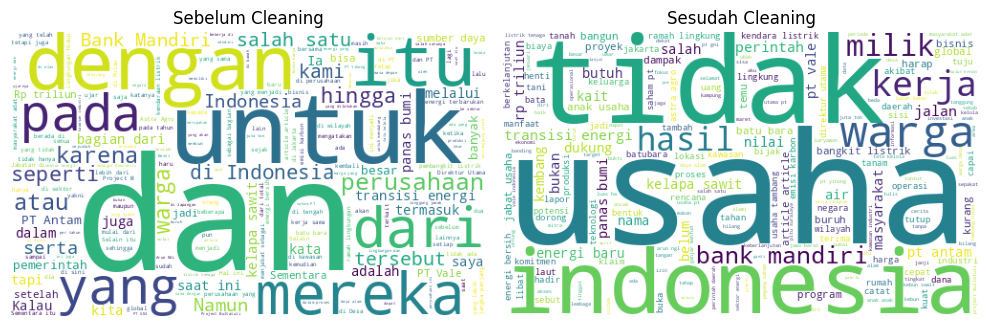

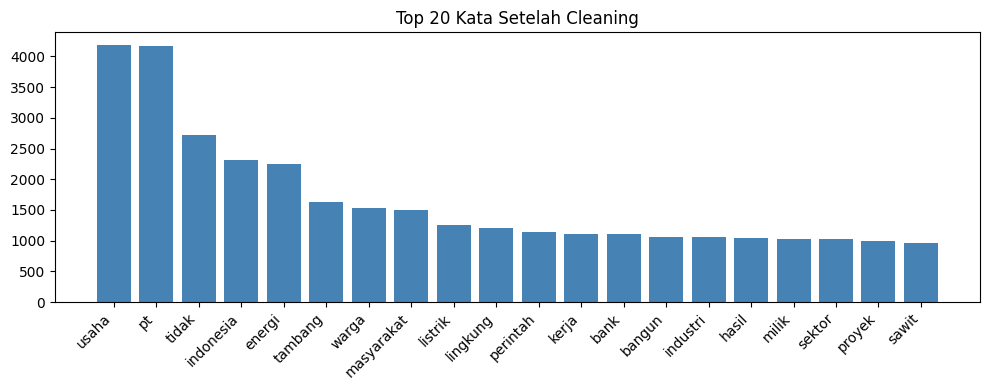

In [ ]:
# WordCloud sebelum cleaning
text_before = " ".join(df[KOLOM_TEKS].dropna().astype(str))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=500, height=300, background_color='white')
           .generate(text_before))
plt.axis("off")
plt.title("Sebelum Cleaning")

# WordCloud sesudah cleaning (dari token yang sudah bersih)
all_tokens = []
for tok_str in df["tokens"]:
    try:
        all_tokens.extend(json.loads(tok_str))
    except Exception:
        pass

text_after = " ".join(all_tokens)
plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=500, height=300, background_color='white')
           .generate(text_after))
plt.axis("off")
plt.title("Sesudah Cleaning")
plt.tight_layout()
plt.savefig("wordcloud_comparison.png", dpi=150)
plt.show()

# Top 20 kata setelah cleaning
word_freq = Counter(all_tokens).most_common(20)
words  = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10, 4))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 Kata Setelah Cleaning")
plt.tight_layout()
plt.savefig("top20_kata.png", dpi=150)
plt.show()

MENYIMPAN OUTPUT

In [ ]:
OUTPUT_FILE = "clean_data.csv"
df.to_csv(OUTPUT_FILE, index=False)
print(f"\nFile disimpan: {OUTPUT_FILE}")
print(f"Total artikel final: {len(df)}")
print("\nList Kolom Setelah Preprocessing:")
for col in df.columns:
    print(f"  - {col}")


File disimpan: clean_data.csv
Total artikel final: 468

List Kolom Setelah Preprocessing:
  - Link
  - Sentiment
  - Penerbit
  - Tag
  - Perusahaan
  - Tahun
  - Isi Berita Clean
  - teks_bersih
  - tokens
  - jumlah_token


In [ ]:
#download
from google.colab import files
files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>